# Imports & Data Filtering

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
from scipy.stats import rankdata, norm, mannwhitneyu, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
import os 
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from plotnine import *

In [2]:
# file paths
DB_PATH = 'human_genome.db' # also needs to be changed in main.py if not this path
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'


SMALL_VARIANTS_PATH = '/s/project/cancer_pred/MASTER/final_res/splicosome_variants.parquet'

In [3]:
SAMPLE_ID = 'random_id'
splicing = pd.read_parquet(SPLICING_DATA_PATH)
small_var = pd.read_parquet(SMALL_VARIANTS_PATH)

# Mannwhitneyu & GLM

In [4]:
small_var['total_splicing_vars'] = small_var['n_germline_splicing_variant'] + small_var['n_somatic_splicing_variant']
carriers = small_var[small_var['total_splicing_vars'] > 0][SAMPLE_ID].unique()

all_ids = splicing[SAMPLE_ID].unique()
outlier_burden = splicing.groupby(SAMPLE_ID).size().reindex(all_ids, fill_value=0)
outlier_burden = outlier_burden.reset_index(name='burden')

outlier_burden['is_carrier'] = outlier_burden[SAMPLE_ID].isin(carriers).astype(int)

In [5]:
carrier_burden = outlier_burden[outlier_burden['is_carrier'] == 1]['burden']
non_carrier_burden = outlier_burden[outlier_burden['is_carrier'] == 0]['burden']

stat, p_val = mannwhitneyu(carrier_burden, non_carrier_burden, alternative='greater')

In [6]:
p_val

np.float64(0.02054607809074802)

In [7]:
outlier_burden['burden'] = outlier_burden['burden'].astype(int)

model = smf.glm(formula='burden ~ is_carrier', 
                data=outlier_burden, 
                family=sm.families.NegativeBinomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 burden   No. Observations:                 3655
Model:                            GLM   Df Residuals:                     3653
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20937.
Date:                Mon, 21 Sep 2026   Deviance:                       8651.4
Time:                        18:37:53   Pearson chi2:                 2.46e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          8.789e-05
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7181      0.019    243.120      0.0

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.


# Separate Germline & Somatic analysis

In [8]:
germline = pd.read_parquet(GERMLINE_DATA_PATH)
somatic = pd.read_parquet(SOMATIC_DATA_PATH)

In [9]:
germline_carriers = small_var[small_var['n_germline_splicing_variant'] > 0]['random_id'].unique()
somatic_carriers = small_var[small_var['n_somatic_splicing_variant'] > 0]['random_id'].unique()

In [10]:
def test_outlier_burden(carrier_ids, all_sample_ids, outlier_df):
    burden_df = outlier_df.groupby(SAMPLE_ID).size().reindex(all_sample_ids, fill_value=0).reset_index(name='burden')
    burden_df['is_carrier'] = burden_df[SAMPLE_ID].isin(carrier_ids).astype(int)
    
    model = smf.glm(formula='burden ~ is_carrier', 
                    data=burden_df, 
                    family=sm.families.NegativeBinomial()).fit()
    return model

germline_model = test_outlier_burden(germline_carriers, all_ids, splicing)
print("Germline Results:")
print(germline_model.summary())

somatic_model = test_outlier_burden(somatic_carriers, all_ids, splicing)
print("Somatic Results:")
print(somatic_model.summary())

Germline Results:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 burden   No. Observations:                 3655
Model:                            GLM   Df Residuals:                     3653
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20936.
Date:                Mon, 21 Sep 2026   Deviance:                       8651.0
Time:                        18:39:43   Pearson chi2:                 2.46e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0002061
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7167      0.018  

/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.


# Per-gene testing

In [11]:
def gene_specific_test(gene, small_var, splicing_df, all_samples):
    carriers = small_var[small_var['Gene'] == gene]['random_id'].unique()
    
    outliers = splicing_df[splicing_df['geneID_short'] == gene]['random_id'].unique()

    carrier_outlier = len(set(carriers) & set(outliers))
    carrier_no_outlier = len(carriers) - carrier_outlier
    non_carrier_outlier = len(set(outliers) - set(carriers))
    non_carrier_no_outlier = len(all_samples) - (carrier_outlier + carrier_no_outlier + non_carrier_outlier)
    
    table = [[carrier_outlier, carrier_no_outlier], 
             [non_carrier_outlier, non_carrier_no_outlier]]
    
    _, p_val = fisher_exact(table, alternative='greater')
    return p_val

In [12]:
unique_genes = small_var['Gene'].unique() #133
gene_pvals = {g: gene_specific_test(g, small_var, splicing, all_ids) for g in unique_genes}

In [13]:
results_df = pd.DataFrame.from_dict(gene_pvals, orient='index', columns=['p_val'])
results_df.index.name = 'Gene'
stats_df = results_df.reset_index()

genes = stats_df[stats_df['p_val'] < 0.05].sort_values('p_val')

In [14]:
reject, padj, _, _ = multipletests(stats_df['p_val'], method='fdr_bh')
stats_df['padj'] = padj

sig_genes_fdr = stats_df[stats_df['padj'] < 0.05].sort_values('padj')

In [15]:
carrier_counts = small_var.groupby('Gene')['random_id'].nunique().reset_index()
carrier_counts.columns = ['Gene', 'n_carriers']

stats_df = stats_df.merge(carrier_counts, on='Gene', how='left')

In [16]:
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

stats_df['geneID_filtered'] = stats_df['Gene'].astype(str).str.split('.').str[0].str.strip() 
stats_df['geneID_filtered'] = stats_df['geneID_filtered'].map(id_to_symbol).fillna(stats_df['geneID_filtered'])

/scratch/tmp/deben/ipykernel_306680/3885884898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



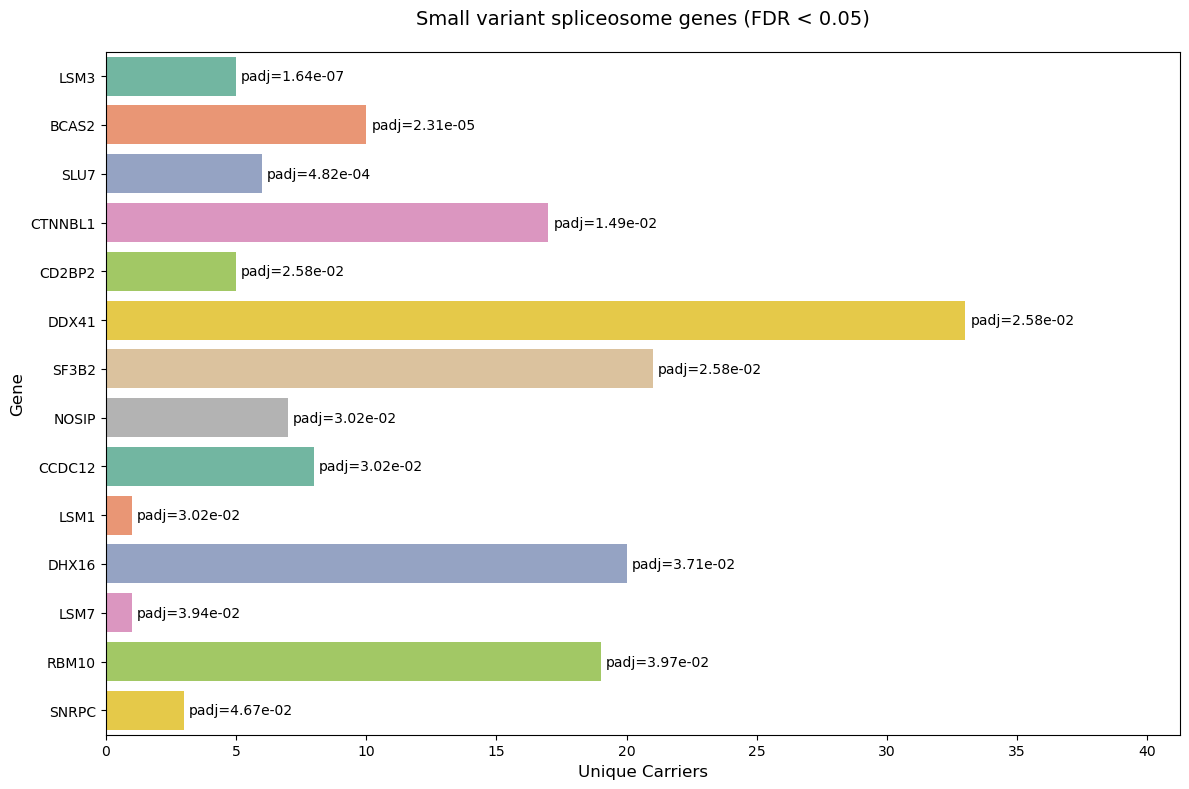

In [17]:
sig_genes_fdr = stats_df[stats_df['padj'] < 0.05].sort_values('padj')

plt.figure(figsize=(12, 8))

sns.barplot(
    data=sig_genes_fdr,
    x='n_carriers',
    y='geneID_filtered',
    palette='Set2'
)

for index, row in sig_genes_fdr.reset_index(drop=True).iterrows():
    x_pos = row['n_carriers']
    padj_text = f"padj={row['padj']:.2e}"
    plt.text(x_pos + 0.2, index, padj_text, va='center', fontsize=10)

plt.title("Small variant spliceosome genes (FDR < 0.05)", fontsize=14, pad=20)
plt.xlabel("Unique Carriers", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.xlim(0, sig_genes_fdr['n_carriers'].max() + (sig_genes_fdr['n_carriers'].max() * 0.25))

plt.tight_layout()
plt.show()

# Rank-sum testing

In [18]:
# wilcoxon rank sum test + FDR correction => this test is not chromosome 'aware'
def stats_test_no_chrom_awareness(genes_to_test, res_df, burden_df, filter_sig=True):
    if not genes_to_test:
        return pd.DataFrame()

    burden_df = burden_df.copy()
    burden_df['global_rank'] = rankdata(burden_df['burden'])
    N = len(burden_df)

    res_filtered = res_df[res_df['geneID_filtered'].isin(genes_to_test)]
    unique_carriers = res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

    merged = unique_carriers.merge(
        burden_df[[SAMPLE_ID, 'global_rank']],
        on=SAMPLE_ID,
        how='inner'
    )

    stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
        n_carriers='count',
        rank_sum='sum'
    ).reset_index()
    stats_df.rename(columns={'geneID_filtered': 'Gene'}, inplace=True)

    n1 = stats_df['n_carriers']
    n2 = N - n1
    s = stats_df['rank_sum']

    expected = n1 * (N + 1) / 2.0
    std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

    z_scores = (s - expected) / std_dev
    stats_df['p_val'] = norm.sf(z_scores)

    stats_df = stats_df.drop(columns=['rank_sum'])

    if not stats_df.empty:
        _, stats_df['padj'], _, _ = multipletests(stats_df['p_val'], method='fdr_bh')

        if filter_sig:
            return stats_df[stats_df['padj'] < 0.05].sort_values('padj')
        else:
            return stats_df.sort_values('p_val')

    return stats_df

# chromosome 'aware' stats test => outliers on the same chromosome as a CNV will be removed
def stats_test(genes_to_test, res_df, chrom_counts_matrix, filter_sig=True, alpha=0.05):
    valid_res = res_df.dropna(subset=['chrom'])

    valid_genes_in_res = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes_in_res]

    results = []

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index
    N = len(all_samples)

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in genes_by_chrom.items():

        current_chrom_outliers = chrom_counts_matrix.get(chrom, 0)
        adj_burden = total_burden_series - current_chrom_outliers

        global_ranks = pd.Series(rankdata(adj_burden), index=all_samples)

        res_subset = valid_res[valid_res['geneID_filtered'].isin(genes)]
        unique_carriers = res_subset.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

        merged = unique_carriers.merge(global_ranks.rename('global_rank'),
                                      left_on=SAMPLE_ID, right_index=True, how='inner')

        stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
            n_carriers='count',
            rank_sum='sum'
        ).reset_index()

        n1 = stats_df['n_carriers']
        n2 = N - n1
        s = stats_df['rank_sum']
        expected = n1 * (N + 1) / 2.0
        std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

        z_scores = (s - expected) / std_dev
        stats_df['p_val'] = norm.sf(z_scores)

        results.append(stats_df)

    if not results:
        return pd.DataFrame()

    final_stats_df = pd.concat(results).rename(columns={'geneID_filtered': 'Gene'})

    if not final_stats_df.empty:
        _, final_stats_df['padj'], _, _ = multipletests(final_stats_df['p_val'], method='fdr_bh')
        if filter_sig:
            return final_stats_df[final_stats_df['padj'] < alpha].sort_values('padj')
        return final_stats_df.sort_values('p_val')

    return final_stats_df

In [19]:
def map_and_clean_ids(df, id_column):
    df['geneID_filtered'] = df[id_column].astype(str).str.split('.').str[0].str.strip() # just for double security
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    return df

splicing = map_and_clean_ids(splicing, 'geneID_short')
small_var = map_and_clean_ids(small_var, 'Gene')

In [20]:
conn = sqlite3.connect(DB_PATH)
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

splicing['chrom'] = splicing['geneID_filtered'].map(gene_chrom_map)
small_var['chrom'] = small_var['geneID_filtered'].map(gene_chrom_map)

In [21]:
def get_chrom_counts(outlier_df, sample_id=SAMPLE_ID):
    return outlier_df.groupby([sample_id, 'chrom']).size().unstack(fill_value=0)

all_ids = splicing[SAMPLE_ID].unique()

chrom_counts_matrix = get_chrom_counts(splicing).reindex(all_ids, fill_value=0)

In [22]:
small_var_genes = small_var['geneID_filtered'].dropna().unique().tolist()

naive_results = stats_test_no_chrom_awareness(
    genes_to_test=small_var_genes,
    res_df=small_var,
    burden_df=outlier_burden,
    filter_sig=False
)

chrom_aware_results = stats_test(
    genes_to_test=small_var_genes,
    res_df=small_var,
    chrom_counts_matrix=chrom_counts_matrix,
    filter_sig=False
)

In [25]:
print("Lowest adj. p-value (naive results): ", naive_results.head(1)['padj'].tolist())
print("Lowest adj. p-value: ", chrom_aware_results.head(1)['padj'].tolist())

Lowest adj. p-value (naive results):  [0.29220805625078344]
Lowest adj. p-value:  [0.3561335356797239]


# Pathway analysis

In [26]:
# pathway agnostic analysis
small_var_genes = small_var['Gene'].dropna().unique().tolist()

conn = sqlite3.connect(DB_PATH)
placeholders = ','.join('?' * len(small_var_genes))

query_pathways = f"""
    SELECT DISTINCT pathway_name 
    FROM pathways 
    WHERE ensembl_id IN ({placeholders})
"""
relevant_pathways = pd.read_sql(query_pathways, conn, params=small_var_genes)['pathway_name'].tolist()
print(f"Total pathways containing >=1 small variant gene: {len(relevant_pathways)}")

Total pathways containing >=1 small variant gene: 78


In [27]:
MAX_CARRIER_FREQ = 0.15  
JACCARD_DISTANCE_THRESHOLD = 0.5  
MIN_CARRIERS = 5 

total_patients = len(outlier_burden[SAMPLE_ID].unique())
max_carriers_allowed = total_patients * MAX_CARRIER_FREQ

new_formula = "burden ~ has_defect"

pathway_results = []
pathway_gene_map = {}

In [28]:
for pathway in tqdm(relevant_pathways, desc="Testing Pathways"):
    query_genes = """
        SELECT pathways.ensembl_id, genes.symbol 
        FROM pathways 
        JOIN genes ON pathways.ensembl_id = genes.ensembl_gene_id
        WHERE pathways.pathway_name = ?
    """
    pw_df = pd.read_sql(query_genes, conn, params=(pathway,))
    pw_ensembl_ids = pw_df['ensembl_id'].unique().tolist()

    if len(pw_ensembl_ids) < 5 or len(pw_ensembl_ids) > 200: 
        continue
        
    pathway_carriers = small_var[
        (small_var['Gene'].isin(pw_ensembl_ids)) & 
        (small_var['total_splicing_vars'] > 0)
    ][SAMPLE_ID].unique()
    
    if len(pathway_carriers) > max_carriers_allowed or len(pathway_carriers) < MIN_CARRIERS:
        continue
        
    pathway_gene_map[pathway] = set(pw_ensembl_ids)
    outlier_burden['has_defect'] = outlier_burden[SAMPLE_ID].isin(pathway_carriers).astype(int)
    
    try:
        model = smf.negativebinomial(
            formula=new_formula, 
            data=outlier_burden
        ).fit(disp=0, maxiter=100)
        
        pathway_results.append({
            'Pathway': pathway,
            'P_Value': model.pvalues['has_defect'],
            'Coef': model.params['has_defect']
        })
        
    except Exception as e:
        continue

pathway_df = pd.DataFrame(pathway_results)

conn.close()

Testing Pathways:   0%|          | 0/78 [00:00<?, ?it/s]

In [29]:
sample_disease_map = splicing[[SAMPLE_ID, 'Oncotree Code']].drop_duplicates(subset=[SAMPLE_ID])

MIN_DIAG_N = 50
diag_counts = sample_disease_map['Oncotree Code'].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_DIAG_N].index.tolist()

outlier_burden_diag = outlier_burden.merge(sample_disease_map, on=SAMPLE_ID, how='left')
outlier_burden_diag = outlier_burden_diag[outlier_burden_diag['Oncotree Code'].isin(valid_diags)].copy()

print(f"{len(valid_diags)} diagnoses retained (n>={MIN_DIAG_N}), "
      f"{len(outlier_burden_diag)}/{len(outlier_burden)} samples retained")

adj_formula = "burden ~ has_defect + C(Q('Oncotree Code'))"

pathway_results_adj = []

conn = sqlite3.connect(DB_PATH)
for pathway in tqdm(relevant_pathways, desc="Testing Pathways (diag-adjusted)"):
    query_genes = """
        SELECT pathways.ensembl_id, genes.symbol 
        FROM pathways 
        JOIN genes ON pathways.ensembl_id = genes.ensembl_gene_id
        WHERE pathways.pathway_name = ?
    """
    pw_df = pd.read_sql(query_genes, conn, params=(pathway,))
    pw_ensembl_ids = pw_df['ensembl_id'].unique().tolist()

    if len(pw_ensembl_ids) < 5 or len(pw_ensembl_ids) > 200:
        continue

    pathway_carriers = small_var[
        (small_var['Gene'].isin(pw_ensembl_ids)) &
        (small_var['total_splicing_vars'] > 0)
    ][SAMPLE_ID].unique()

    if len(pathway_carriers) > max_carriers_allowed or len(pathway_carriers) < MIN_CARRIERS:
        continue

    df = outlier_burden_diag.copy()
    df['has_defect'] = df[SAMPLE_ID].isin(pathway_carriers).astype(int)

    carrier_diag_spread = df.loc[df['has_defect'] == 1, 'Oncotree Code'].nunique()
    if carrier_diag_spread < 2:
        continue

    try:
        model_adj = smf.negativebinomial(formula=adj_formula, data=df).fit(disp=0, maxiter=200)
        pathway_results_adj.append({
            'Pathway': pathway,
            'n_carriers': len(pathway_carriers),
            'P_Value_adj_model': model_adj.pvalues['has_defect'],
            'Coef_adj_model': model_adj.params['has_defect'],
            'converged': model_adj.mle_retvals.get('converged', 'n/a')
        })
    except Exception as e:
        continue

conn.close()

pathway_df_adj = pd.DataFrame(pathway_results_adj)
if not pathway_df_adj.empty:
    _, pathway_df_adj['padj_adj_model'], _, _ = multipletests(
        pathway_df_adj['P_Value_adj_model'].fillna(1.0), method='fdr_bh'
    )

17 diagnoses retained (n>=50), 1215/3655 samples retained


Testing Pathways (diag-adjusted):   0%|          | 0/78 [00:00<?, ?it/s]

In [30]:
sig_pathways_adj = pathway_df_adj[(pathway_df_adj['padj_adj_model'] < 0.05)].copy()

if len(sig_pathways_adj) > 1:
    top_pathway_names_adj = sig_pathways_adj['Pathway'].tolist()
    
    def jaccard_dist(u, v):
        i, j = int(u[0]), int(v[0])
        set_a = pathway_gene_map[top_pathway_names_adj[i]]
        set_b = pathway_gene_map[top_pathway_names_adj[j]]
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        return 1.0 - (intersection / union if union > 0 else 0)

    indices = np.arange(len(top_pathway_names_adj), dtype=float)[:, None]
    distance_matrix_adj = pdist(indices, metric=jaccard_dist)
    Z = linkage(distance_matrix_adj, method='average')
    
    cluster_labels = fcluster(Z, t=JACCARD_DISTANCE_THRESHOLD, criterion='distance')
    sig_pathways_adj['Cluster'] = cluster_labels
    
    independent_nodes = sig_pathways_adj.loc[sig_pathways_adj.groupby('Cluster')['Coef_adj_model'].idxmax()]
    independent_nodes = independent_nodes.sort_values('padj_adj_model')
else:
    independent_nodes = sig_pathways_adj

print("\nTop Independent Pathways:")
display(independent_nodes.head(20))


Top Independent Pathways:


,Pathway,n_carriers,P_Value_adj_model,Coef_adj_model,converged,padj_adj_model,Cluster
49,Regulation of innate immune responses to cytos...,33,0.000533,-1.662660,True,0.009065,1
50,IRF3-mediated induction of type I IFN,33,0.000533,-1.662660,True,0.009065,2
48,STING mediated induction of host immune responses,33,0.000533,-1.662660,True,0.009065,3
40,Gene and protein expression by JAK-STAT signal...,8,0.002707,2.163268,True,0.034511,6
1,Formation of TC-NER Pre-Incision Complex,83,0.007139,-0.720426,True,0.045509,4
5,mRNA Splicing - Minor Pathway,236,0.008481,0.485415,True,0.048059,5


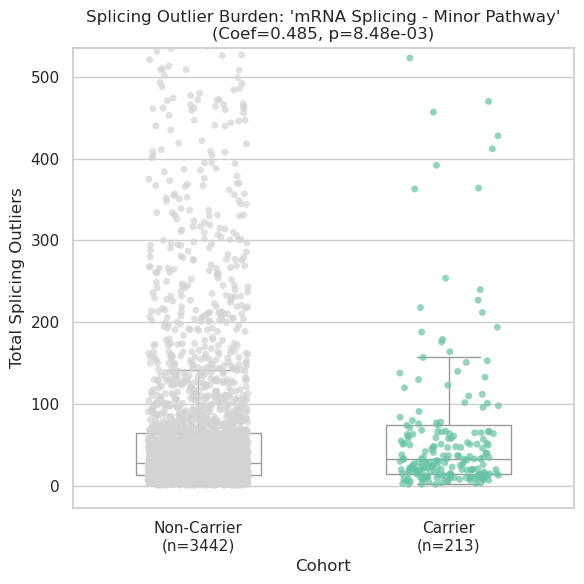

In [31]:
truncate_y_axis = True
y_axis_quantile_limit = 0.95 

top_n = 6
top_pathways = independent_nodes.sort_values('padj_adj_model').head(top_n)['Pathway'].tolist()
set2_palette = sns.color_palette("Set2", n_colors=top_n)

if truncate_y_axis:
    y_max = outlier_burden['burden'].quantile(y_axis_quantile_limit)

top_pathways = independent_nodes.sort_values('padj_adj_model').tail(1)['Pathway'].tolist()

for i, pathway in enumerate(top_pathways):
    pw_genes = pathway_gene_map[pathway]
    outlier_burden['is_carrier'] = outlier_burden[SAMPLE_ID].isin(
        small_var[(small_var['Gene'].isin(pw_genes)) & (small_var['total_splicing_vars'] > 0)][SAMPLE_ID].unique()
    ).astype(int)
    
    counts = outlier_burden['is_carrier'].value_counts()
    n_non_carrier = counts.get(0, 0)
    n_carrier = counts.get(1, 0)
    
    pathway_palette = {0: '#d3d3d3', 1: set2_palette[i]}
    
    plt.figure(figsize=(6, 6))
    sns.set_theme(style="whitegrid")
    
    sns.boxplot(
        data=outlier_burden, x='is_carrier', y='burden', 
        color='white', width=0.5, showfliers=False, order=[0, 1]
    )
    
    sns.stripplot(
        data=outlier_burden, x='is_carrier', y='burden', 
        hue='is_carrier', palette=pathway_palette, 
        jitter=0.2, size=5, alpha=0.7, legend=False, order=[0, 1]
    )
    
    p_val = independent_nodes.loc[independent_nodes['Pathway'] == pathway, 'P_Value_adj_model'].values[0]
    coef = independent_nodes.loc[independent_nodes['Pathway'] == pathway, 'Coef_adj_model'].values[0]
    
    plt.title(f"Splicing Outlier Burden: '{pathway}'\n(Coef={coef:.3f}, p={p_val:.2e})", fontsize=12)
    plt.xticks(ticks=[0, 1], labels=[f'Non-Carrier\n(n={n_non_carrier})', f'Carrier\n(n={n_carrier})'])
    plt.ylabel("Total Splicing Outliers", fontsize=12)
    plt.xlabel("Cohort", fontsize=12)
    
    if truncate_y_axis:
        plt.ylim(bottom=-max(1, y_max * 0.05), top=y_max)
        
    plt.tight_layout()
    plt.show()

# Testing overall burden across groups

In [ ]:
all_carriers = small_var[small_var['total_splicing_vars'] > 0].copy()
all_carriers['origin'] = 'Combined'

germline_only = small_var[small_var['n_germline_splicing_variant'] > 0].copy()
germline_only['origin'] = 'Germline'

somatic_only = small_var[small_var['n_somatic_splicing_variant'] > 0].copy()
somatic_only['origin'] = 'Somatic'

carriers_combined = pd.concat([all_carriers, germline_only, somatic_only])

In [34]:
# Rebekas code
total_carriers = small_var[small_var['total_splicing_vars'] > 0][SAMPLE_ID].unique()
germline_carriers = small_var[small_var['n_germline_splicing_variant'] > 0][SAMPLE_ID].unique()
somatic_carriers = small_var[small_var['n_somatic_splicing_variant'] > 0][SAMPLE_ID].unique()

all_ids = splicing[SAMPLE_ID].unique()
sample_counts = splicing.groupby(SAMPLE_ID).size().reindex(all_ids, fill_value=0).reset_index(name='count')

sample_counts['has_total_variant'] = sample_counts[SAMPLE_ID].isin(total_carriers)
sample_counts['has_germline_variant'] = sample_counts[SAMPLE_ID].isin(germline_carriers)
sample_counts['has_somatic_variant'] = sample_counts[SAMPLE_ID].isin(somatic_carriers)

In [35]:
columns = ["has_total_variant", "has_germline_variant", "has_somatic_variant"]

dropdown = widgets.Dropdown(options=columns, description="Group by:")
output = widgets.Output()

def plot(col):
    with output:
        clear_output(wait=True)
        p = (
            ggplot(sample_counts, aes(y="count", color=col, x=col))
            + geom_boxplot()
            + scale_y_log10()
            + geom_violin(alpha=0.5)
        )
        p.show()

dropdown.observe(lambda change: plot(change["new"]), names="value")
plot(columns[0])

display(dropdown, output)

Dropdown(description='Group by:', options=('has_total_variant', 'has_germline_variant', 'has_somatic_variant')…

Output()

In [36]:
for col_name in columns:
    group1 = sample_counts[sample_counts[col_name] == True]["count"].tolist()
    group2 = sample_counts[sample_counts[col_name] == False]["count"].tolist()

    stat, pvalue = mannwhitneyu(group1, group2)
    print(f"--- {col_name} ---")
    print(f"Median with variant: {np.median(group1):.2f}")
    print(f"Median without variant: {np.median(group2):.2f}")
    print(f"p-value: {pvalue:.3e}\n")

--- has_total_variant ---
Median with variant: 30.50
Median without variant: 28.00
p-value: 4.109e-02

--- has_germline_variant ---
Median with variant: 29.00
Median without variant: 28.00
p-value: 7.377e-01

--- has_somatic_variant ---
Median with variant: 36.00
Median without variant: 28.00
p-value: 2.783e-04



In [37]:
impact_ids = splicing[splicing['IMPACT'] == 'HIGH'][SAMPLE_ID].unique()
sample_counts['has_HIGH_impact'] = sample_counts[SAMPLE_ID].isin(impact_ids)

group1 = sample_counts[sample_counts["has_HIGH_impact"] == True]["count"].tolist()
group2 = sample_counts[sample_counts["has_HIGH_impact"] == False]["count"].tolist()

stat, pvalue = mannwhitneyu(group1, group2)
print(f"Median with HIGH impact: {np.median(group1):.2f}")
print(f"Median without HIGH impact: {np.median(group2):.2f}")
print(f"p-value: {pvalue:.3e}")

Median with HIGH impact: 36.00
Median without HIGH impact: 20.00
p-value: 1.570e-57


# Analysis by diagnosis

In [38]:
DIAG_COL = 'Oncotree Code' 
MIN_SAMPLES = 50

In [39]:
sample_disease_map = splicing[[SAMPLE_ID, DIAG_COL]].drop_duplicates(subset=[SAMPLE_ID])

spliceosome_carriers = small_var[small_var['total_splicing_vars'] > 0][SAMPLE_ID].unique()

analysis_df = outlier_burden.merge(sample_disease_map, on=SAMPLE_ID, how='inner')
analysis_df['is_carrier'] = analysis_df[SAMPLE_ID].isin(spliceosome_carriers).astype(int)

diag_counts = analysis_df[DIAG_COL].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_SAMPLES].index.tolist()

print(f"{len(valid_diags)} groups with >= {MIN_SAMPLES} samples")

17 groups with >= 50 samples


In [40]:
diag_results = []

for diag in tqdm(valid_diags, desc="Analyzing by Diagnosis"):
    df_subset = analysis_df[analysis_df[DIAG_COL] == diag].copy()
    
    n_total = len(df_subset)
    n_carriers = df_subset['is_carrier'].sum()
    n_non_carriers = n_total - n_carriers
    
    carrier_burden = df_subset[df_subset['is_carrier'] == 1]['burden']
    non_carrier_burden = df_subset[df_subset['is_carrier'] == 0]['burden']
    
    if n_carriers > 0 and n_non_carriers > 0:
        stat, p_val = mannwhitneyu(carrier_burden, non_carrier_burden, alternative='greater')
    else:
        p_val = np.nan
        
    diag_results.append({
        'Diagnosis': diag,
        'Total_Samples': n_total,
        'Carriers': n_carriers,
        'Carrier_Freq(%)': (n_carriers / n_total) * 100,
        'Median_Burden_Carriers': carrier_burden.median() if n_carriers > 0 else np.nan,
        'Median_Burden_NonCarriers': non_carrier_burden.median() if n_non_carriers > 0 else np.nan,
        'P_Value': p_val
    })

Analyzing by Diagnosis:   0%|          | 0/17 [00:00<?, ?it/s]

In [45]:
diag_stats_df = pd.DataFrame(diag_results).dropna(subset=['P_Value'])

_, diag_stats_df['padj'], _, _ = multipletests(diag_stats_df['P_Value'], method='fdr_bh')
diag_stats_df = diag_stats_df.sort_values('P_Value')

print("\n--- Diagnosis Stratified Results ---")
display(diag_stats_df.head(20)[['Diagnosis', 'P_Value', 'padj']])


--- Diagnosis Stratified Results ---


,Diagnosis,P_Value,padj
7,UM,0.014531,0.247035
16,GIST,0.029482,0.250598
15,PANET,0.077483,0.415347
1,ACC,0.140818,0.415347
3,SYNS,0.145644,0.415347
10,ADNOS,0.146593,0.415347
2,COAD,0.183370,0.445327
9,MFH,0.243727,0.517920
4,UNCMAL,0.300081,0.566820
11,SARCNOS,0.422285,0.629059


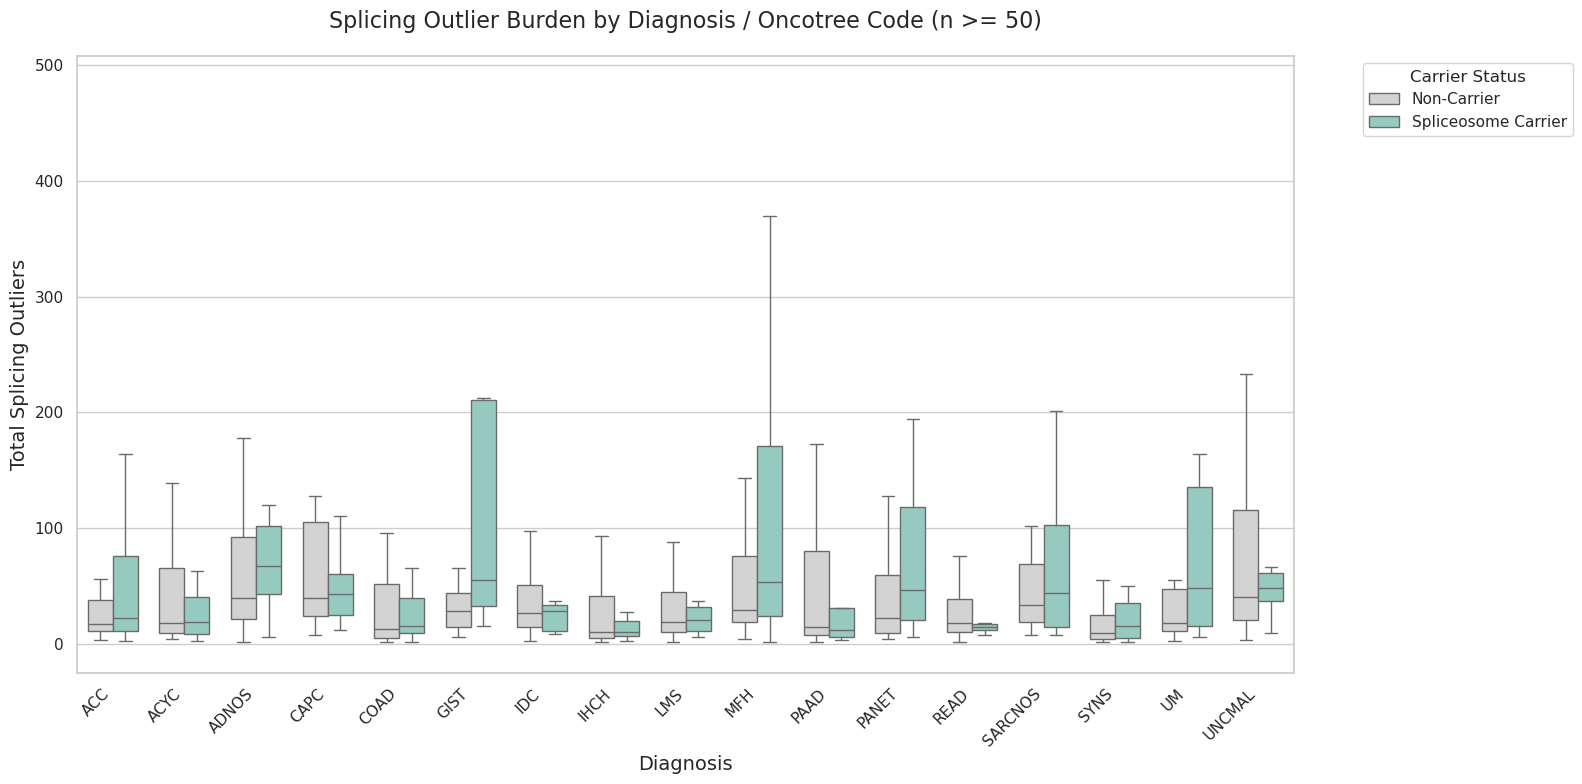

In [46]:
plot_df = analysis_df[analysis_df[DIAG_COL].isin(valid_diags)].copy()
plot_df = plot_df.sort_values(by=DIAG_COL)

plot_df['Status'] = plot_df['is_carrier'].map({0: 'Non-Carrier', 1: 'Spliceosome Carrier'})

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

y_max = plot_df['burden'].quantile(0.95)

sns.boxplot(
    data=plot_df, 
    x=DIAG_COL, 
    y='burden', 
    hue='Status',
    palette={'Non-Carrier': '#d3d3d3', 'Spliceosome Carrier': '#8dd3c7'},
    width=0.7,
    showfliers=False
)

plt.title(f'Splicing Outlier Burden by Diagnosis / {DIAG_COL} (n >= {MIN_SAMPLES})', fontsize=16, pad=20)
plt.ylabel('Total Splicing Outliers', fontsize=14)
plt.xlabel('Diagnosis', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=-max(1, y_max * 0.05), top=y_max)
plt.legend(title='Carrier Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

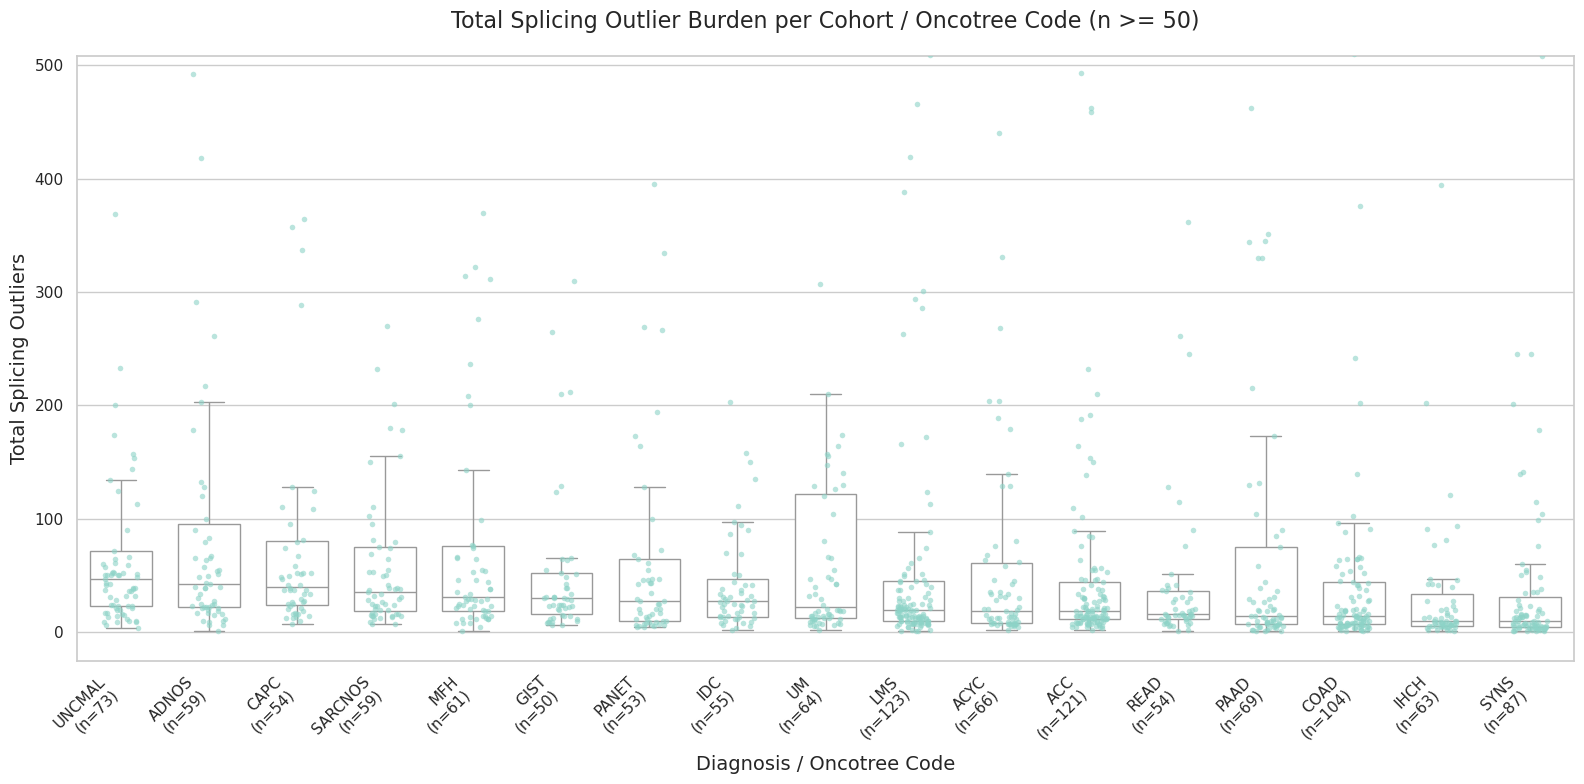

In [47]:
diag_counts = analysis_df[DIAG_COL].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_SAMPLES].index.tolist()
plot_df = analysis_df[analysis_df[DIAG_COL].isin(valid_diags)].copy()

median_order = plot_df.groupby(DIAG_COL)['burden'].median().sort_values(ascending=False).index
plot_df[DIAG_COL] = pd.Categorical(plot_df[DIAG_COL], categories=median_order, ordered=True)
plot_df = plot_df.sort_values(DIAG_COL)

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

if truncate_y_axis:
    y_max = plot_df['burden'].quantile(y_axis_quantile_limit)

sns.boxplot(
    data=plot_df, 
    x=DIAG_COL, 
    y='burden', 
    color='white',
    width=0.7,
    showfliers=False
)

sns.stripplot(
    data=plot_df, 
    x=DIAG_COL, 
    y='burden', 
    color='#8dd3c7',
    jitter=0.2, 
    size=4, 
    alpha=0.6
)

plt.title(f'Total Splicing Outlier Burden per Cohort / {DIAG_COL} (n >= {MIN_SAMPLES})', fontsize=16, pad=20)
plt.ylabel('Total Splicing Outliers', fontsize=14)
plt.xlabel('Diagnosis / Oncotree Code', fontsize=14)

tick_labels = [f"{diag}\n(n={diag_counts[diag]})" for diag in median_order]
plt.xticks(ticks=range(len(median_order)), labels=tick_labels, rotation=45, ha='right')

if truncate_y_axis:
    plt.ylim(bottom=-max(1, y_max * 0.05), top=y_max)

plt.tight_layout()
plt.show()